# Laboratorium 8: Modele oświetlenia


In [ ]:
import numpy as np
import sys

sys.setrecursionlimit(100000)


def floodfill(Image, x, y, newColor):
    imgCopy = Image.copy()

    def floodfill_inplace(Image, x, y, newColor):
        oldColor = Image[y][x].copy()
        if (oldColor == newColor).all():
            return
        Image[y][x] = newColor
        if x > 0 and (Image[y][x - 1] == oldColor).all():
            floodfill_inplace(Image, x - 1, y, newColor)
        if x < len(Image[0]) - 1 and (Image[y][x + 1] == oldColor).all():
            floodfill_inplace(Image, x + 1, y, newColor)
        if y > 0 and (Image[y - 1][x] == oldColor).all():
            floodfill_inplace(Image, x, y - 1, newColor)
        if y < len(Image) - 1 and (Image[y + 1][x] == oldColor).all():
            floodfill_inplace(Image, x, y + 1, newColor)

    floodfill_inplace(imgCopy, x, y, newColor)
    return imgCopy


def linia1(Im1, yp, xp, yk, xk, C):
    """
    Im1 - input image
    (yp, xp) - starting point of the line
    (yk, xk) - ending point of the line
    C - color of the line
    """
    Y, X, _ = Im1.shape
    Im2 = Im1.copy()

    if abs(yk - yp) > abs(xk - xp):
        x0, y0, x1, y1 = yp, xp, yk, xk
        zamiana = 1
    else:
        x0, y0, x1, y1 = xp, yp, xk, yk
        zamiana = 0

    if zamiana == 1:
        X, Y = Y, X

    if x0 > x1:
        x0, x1 = x1, x0
        y0, y1 = y1, y0

    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sy = 1 if y1 > y0 else (-1 if y1 < y0 else 0)

    x, y = x0, y0

    def draw_point(px, py):
        if 0 <= px < X and 0 <= py < Y:
            if zamiana == 0:
                Im2[py, px] = C
            else:
                Im2[px, py] = C

    draw_point(x, y)

    error = 2 * dy - dx
    for _ in range(dx):
        error += 2 * dy
        if error > 0:
            y += sy
            error -= 2 * dx
        x += 1
        draw_point(x, y)

    return Im2


def mat2pix(m, n, dx, dy, x, y):
    """
    m, n - size of the image in pixels
    dx, dy - size of the image in math coordinates
    x, y - math coordinates of the point
    """
    transformMatrix = np.array([[1 / dx, 0, 0.5 * m], [0, -1 / dy, 0.5 * n], [0, 0, 1]])

    pixelCoords = np.dot(transformMatrix, np.array([x, y, 1]))
    return round(pixelCoords[0] / pixelCoords[2], 0), round(
        pixelCoords[1] / pixelCoords[2], 0
    )


def pix2mat(m, n, dx, dy, u, v):
    transformMatrix = np.array(
        [[dx, 0, -0.5 * m * dx], [0, -dy, 0.5 * n * dy], [0, 0, 1]]
    )

    mathCords = np.dot(transformMatrix, np.array([u, v, 1]))
    return (mathCords[0] / mathCords[2]), (mathCords[1] / mathCords[2])


def Persp(f):
    H = np.zeros((4, 4), dtype=float)
    H[0, 0] = 1.0
    H[1, 1] = 1.0
    H[3, 2] = -1.0 / f
    H[3, 3] = 1.0
    return H


def plane(p1, p2, p3):
    """
    Wyznacza równanie płaszczyzny przechodzącej przez trzy punkty 3D.

    Argumenty:
    p1, p2, p3 : array-like o długości 3
        Punkty 3D w postaci [x, y, z].

    Zwraca:
    tuple[float, float, float, float]
        Współczynniki (A, b, c, d) równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Wyjątki:
    ValueError
        Gdy punkty są współliniowe i nie wyznaczają jednoznacznej płaszczyzny.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v1, v2)

    if np.allclose(normal, 0.0):
        raise ValueError("Punkty są współliniowe - nie wyznaczają płaszczyzny.")

    A, b, c = normal
    d = -np.dot(normal, p1)
    return float(A), float(b), float(c), float(d)


def normal_vector(p1, p2, p3):
    """
    Wyznacza wektor normalny płaszczyzny określonej przez trzy punkty 3D.

    Argumenty:
    p1, p2, p3 : array-like o długości 3
        Punkty 3D w postaci [x, y, z].

    Zwraca:
    tuple[float, float, float]
        Składowe wektora normalnego (nx, ny, nz).

    Wyjątki:
    ValueError
        Gdy punkty są współliniowe i nie wyznaczają jednoznacznej płaszczyzny.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v2, v1)

    if np.allclose(normal, 0.0):
        raise ValueError("Punkty są współliniowe - nie wyznaczają płaszczyzny.")

    return float(normal[0]), float(normal[1]), float(normal[2])


def distance2plane(point, A, b, c, d):
    """
    Oblicza odległość punktu 3D od płaszczyzny oraz wyznacza punkt na płaszczyźnie,
    do którego padła prostopadła z danego punktu.

    Argumenty:
    point : array-like o długości 3
        Punkt 3D w postaci [x, y, z].
    A, b, c, d : float
        Współczynniki równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Zwraca:
    tuple[float, np.ndarray]
        - float: Nieujemna odległość punktu od płaszczyzny.
        - np.ndarray: Punkt 3D na płaszczyźnie (rzut prostopadły danego punktu).

    Wyjątki:
    ValueError
        Gdy wektor normalny płaszczyzny ma długość zero.
    """
    point = np.asarray(point, dtype=float)
    x, y, z = point

    mianownik = A**2 + b**2 + c**2

    if np.isclose(mianownik, 0.0):
        raise ValueError(
            "Nieprawidłowa płaszczyzna: A, b, c nie mogą być jednocześnie zerowe."
        )

    licznik = A * x + b * y + c * z + d

    # Parametr t dla punktu na płaszczyźnie (rzut prostopadły)
    t = -licznik / mianownik

    # Współrzędne punktu na płaszczyźnie
    x_plane = x + t * A
    y_plane = y + t * b
    z_plane = z + t * c
    plane_point = np.array([x_plane, y_plane, z_plane])

    # Odległość
    distance = np.abs(licznik) / np.sqrt(mianownik)

    return float(distance), plane_point


def lambert_intensity(
    ambient_intensity=0,
    lights=[],
    x=0,
    y=0,
    z=0,
    normalVector=(0, 0, 1),
    epsilon=1,
    alfa=0.001,
    triangle_plane=None,
):
    """
    Oblicza natężenie światła padającego na punkt 3D zgodnie z modelem oświetlenia Lamberta.

    Argumenty:
    ambient_intensity : float
        Natężenie światła otoczenia (ambient light).
    lights : list of tuples
        Lista źródeł światła, gdzie każde źródło jest reprezentowane jako krotka (intensity, (lx, ly, lz)).
    x, y, z : float
        Współrzędne punktu 3D, dla którego obliczamy natężenie.
    normalVector : tuple of floats
        Wektor normalny do powierzchni w punkcie (nx, ny, nz).
    epsilon : float
        Mała wartość dodawana do mianownika, aby uniknąć dzielenia przez zero.

    Zwraca:
    float
        Obliczone natężenie światła padającego na punkt 3D.

    Wyjątki:
    ValueError
        Gdy wektor normalny ma długość zero lub gdy intensywność światła jest ujemna.
    """
    nx, ny, nz = normalVector
    normal_length = np.sqrt(nx**2 + ny**2 + nz**2)

    if np.isclose(normal_length, 0.0):
        raise ValueError("Wektor normalny nie może mieć długości zero.")

    if ambient_intensity < 0:
        raise ValueError("Natężenie światła otoczenia nie może być ujemne.")

    total_intensity = ambient_intensity

    for intensity, (lx, ly, lz) in lights:
        if intensity < 0:
            raise ValueError("Intensywność światła nie może być ujemna.")

        # wektor od punktu do źródła światła
        light_vector = np.array([lx - x, ly - y, lz - z])
        light_length = np.linalg.norm(light_vector)

        # Jeśli źródło światła jest dokładnie w punkcie, pomijamy je, ponieważ nie ma kierunku światła.
        if np.isclose(light_length, 0.0):
            continue

        light_vector_normalized = light_vector / light_length
        normal_normalized = np.array([nx, ny, nz]) / normal_length

        # kąt między wektorem światła a wektorem normalnym tak jak na wykładzie
        angle_from_light_to_normal = np.dot(normal_normalized, light_vector_normalized)

        total_intensity += (
            epsilon
            * intensity
            / (1 + alfa * light_length**2)
            * max(angle_from_light_to_normal, 0)
        )

    return total_intensity


Triangle normal: (132.0, 24.0, -144.0)
Plane equation coefficients: A=-132.0, b=-24.0, c=144.0, d=-1044.0


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

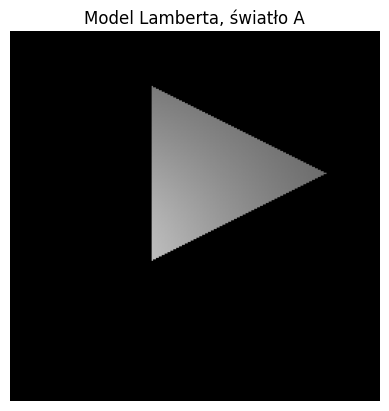

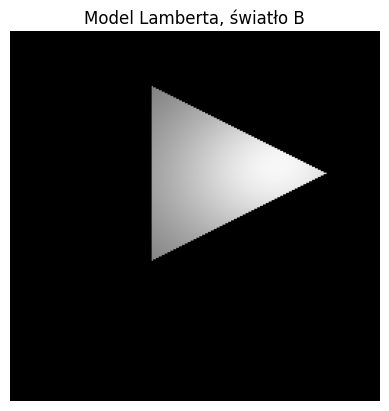

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T1 = np.array([[9, 3, 16], [-3, 9, 6], [-3, -3, 4]], dtype=np.float32)
T1_epsilon = 1
alfa = 0.001

rozdzielczosc_x = 256
rozdzielczosc_y = 256

AmbientLightIntensity = 20

Lights_A = [(235, np.array([-3, -3, -10], dtype=np.float32))]
Lights_B = [(235, np.array([3, 3, 3], dtype=np.float32))]

image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)

T1_11, T1_12 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[0, 0], T1[0, 1])
T1_21, T1_22 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[1, 0], T1[1, 1])
T1_31, T1_32 = mat2pix(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, T1[2, 0], T1[2, 1])

image = linia1(image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (255, 255, 255))
image = linia1(image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (255, 255, 255))
image = linia1(image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (255, 255, 255))
image = floodfill(
    image,
    int(round((T1_11 + T1_21 + T1_31) / 3 + 1)),
    int(round((T1_12 + T1_22 + T1_32) / 3 + 1)),
    (255, 255, 255),
)

# compute plane coefficients for the triangle so we can get correct z at each pixel
A, b, c, d = plane(T1[0], T1[1], T1[2])

normal = normal_vector(T1[0], T1[1], T1[2])

for i in range(rozdzielczosc_x):
    for j in range(rozdzielczosc_y):
        x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)
        plane_distance, plane_point = distance2plane((x, y, 0), A, b, c, d)
        # jeżeli pixel nie jest biały to znaczy że jest tłem i nie trzeba go kolorować
        if (image[i, j] == [0, 0, 0]).all():
            continue

        intensity = lambert_intensity(
            ambient_intensity=AmbientLightIntensity,
            lights=Lights_A,
            x=plane_point[0],
            y=plane_point[1],
            z=plane_point[2],
            normalVector=normal,
            epsilon=T1_epsilon,
            alfa=alfa,
            triangle_plane=(A, b, c, d),
        )
        gray = np.uint8(np.clip(intensity, 0, 255))
        image[i, j] = (gray, gray, gray)

plt.imshow(image, cmap="gray")
plt.title("Model Lamberta, światło A")
plt.axis("off")


image = np.zeros((rozdzielczosc_x, rozdzielczosc_y, 3), dtype=np.uint8)
image = linia1(image, int(T1_12), int(T1_11), int(T1_22), int(T1_21), (255, 255, 255))
image = linia1(image, int(T1_22), int(T1_21), int(T1_32), int(T1_31), (255, 255, 255))
image = linia1(image, int(T1_32), int(T1_31), int(T1_12), int(T1_11), (255, 255, 255))
image = floodfill(
    image,
    int(round((T1_11 + T1_21 + T1_31) / 3 + 1)),
    int(round((T1_12 + T1_22 + T1_32) / 3 + 1)),
    (255, 255, 255),
)

for i in range(rozdzielczosc_x):
    for j in range(rozdzielczosc_y):
        x, y = pix2mat(rozdzielczosc_x, rozdzielczosc_y, 0.1, 0.1, j, i)
        plane_distance, plane_point = distance2plane((x, y, 0), A, b, c, d)

        # jeżeli pixel nie jest biały to znaczy że jest tłem i nie trzeba go kolorować
        if (image[i, j] == [0, 0, 0]).all():
            continue
        intensity = lambert_intensity(
            ambient_intensity=AmbientLightIntensity,
            lights=Lights_B,
            x=plane_point[0],
            y=plane_point[1],
            z=plane_point[2],
            normalVector=normal_vector(T1[0], T1[1], T1[2]),
            epsilon=T1_epsilon,
            alfa=alfa,
        )
        gray = np.uint8(np.clip(intensity, 0, 255))
        image[i, j] = (gray, gray, gray)

plt.figure()
plt.imshow(image, cmap="gray")
plt.title("Model Lamberta, światło B")
plt.axis("off")
